# Needs-Based Financial Recommendation System

**Project structure**
```
project/
├── Silvia_Crestani_def.ipynb   ← this notebook
├── Dataset2_Needs.xls
└── utils/
    ├── __init__.py
    ├── data_loading.py          # load_data
    ├── feature_engineering.py   # prepare_features
    ├── model_utils.py           # train_evaluate_dt, display_results_table, build_train_test_splits
    ├── tuning.py                # optimize_dt  (Optuna)
    ├── shap_utils.py            # build_explainers, permutation_importance_dt
    ├── recommendation.py        # compute_score, generate_recommendations, analyse_coverage
    └── plotting.py              # all plot_* helpers
```
Every function is fully documented in its module — open any `.py` file for
design rationale and parameter descriptions.

## 0 — Imports & global settings

In [32]:
import warnings
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import classification_report
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Feature engineering: usa la funzione canonica del notebook NN ─────────
from NN.features import clean_and_engineer, prepare_model_data

# ── Curve ROC/PR: usa plot_test_curves del notebook NN ────────────────────
from NN.evaluate import plot_test_curves

# ── Tutto il resto e' specifico al pipeline DT ────────────────────────────
from utils import (
    load_data,
    prepare_features,
    train_evaluate_dt,
    display_results_table,
    optimize_dt,
    build_explainers, get_shap_pos, get_base_val,
    permutation_importance_dt,
    compute_score, generate_recommendations, analyse_coverage,
)
from utils.plotting import (
    plot_class_balance,
    plot_confusion_matrices,
    plot_feature_importance,
    plot_cv_fold_performance,
    plot_baseline_vs_tuned,
    plot_shap_bar,
    plot_shap_beeswarm,
    plot_shap_waterfall,
    plot_permutation_importance,
    plot_recommendation_freq,
    plot_suitability_scatter,
    plot_need_probability_hist,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
print('All imports OK.')

All imports OK.


## 1 — Data loading

In [33]:
FILE_PATH = 'Dataset2_Needs.xls'

# load_data strips whitespace from column names and drops the ID column
needs_df, products_df, metadata_df = load_data(FILE_PATH)

print(f'Needs dataset:    {needs_df.shape[0]:,} rows × {needs_df.shape[1]} columns')
print(f'Products dataset: {products_df.shape[0]} products')
needs_df.head()

Needs dataset:    5,000 rows × 9 columns
Products dataset: 11 products


,Age,Gender,FamilyMembers,FinancialEducation,RiskPropensity,Income,Wealth,IncomeInvestment,AccumulationInvestment
0,60,0,2,0.228685,0.233355,68.181525,53.260067,0,1
1,78,0,2,0.358916,0.170911,21.807595,135.550048,1,0
2,33,1,2,0.317515,0.249703,23.252747,66.303678,0,1
3,69,1,4,0.767685,0.654597,166.189034,404.997689,1,1
4,58,0,3,0.429719,0.349039,21.186723,58.911930,0,0


## 2 — Exploratory Data Analysis (EDA)

In [34]:
# Basic data audit: dtypes, missing values, cardinality
info = pd.DataFrame({
    'dtype'  : needs_df.dtypes,
    'missing': needs_df.isna().sum(),
    'unique' : needs_df.nunique()
})
print('=== Data types and missing values ===')
print(info)
print()
print('=== Descriptive statistics ===')
needs_df.describe().round(3)

=== Data types and missing values ===
                          dtype  missing  unique
Age                       int64        0      77
Gender                    int64        0       2
FamilyMembers             int64        0       5
FinancialEducation      float64        0    5000
RiskPropensity          float64        0    5000
Income                  float64        0    5000
Wealth                  float64        0    5000
IncomeInvestment          int64        0       2
AccumulationInvestment    int64        0       2

=== Descriptive statistics ===


,Age,Gender,FamilyMembers,FinancialEducation,RiskPropensity,Income,Wealth,IncomeInvestment,AccumulationInvestment
count,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000,5000.000
mean,55.253,0.492,2.511,0.419,0.363,62.994,93.806,0.384,0.513
std,11.972,0.500,0.762,0.151,0.151,44.360,105.471,0.486,0.500
min,18.000,0.000,1.000,0.036,0.025,1.538,1.057,0.000,0.000
25%,47.000,0.000,2.000,0.308,0.246,30.596,38.311,0.000,0.000
50%,55.000,0.000,3.000,0.417,0.355,53.399,66.071,0.000,1.000
75%,63.000,1.000,3.000,0.523,0.467,84.122,114.825,1.000,1.000
max,97.000,1.000,5.000,0.903,0.883,365.323,2233.228,1.000,1.000


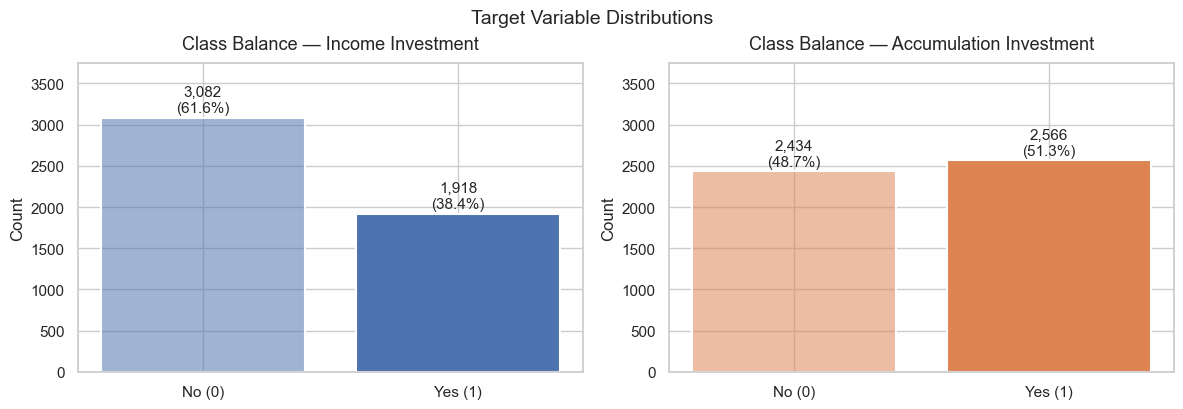

Clients with BOTH needs:    998 (20.0%)
Clients with NEITHER need:  1,514 (30.3%)


In [35]:
# Class balance for both target variables + overlap check
plot_class_balance(needs_df)

## 3 — Feature engineering

In [36]:
# prepare_features returns two feature matrices (see utils/feature_engineering.py)
X_base, X_engineered = prepare_features(needs_df)

# Extract target series for convenience
y_income = needs_df['IncomeInvestment'].reset_index(drop=True)
y_accum  = needs_df['AccumulationInvestment'].reset_index(drop=True)

print('Base features:      ', list(X_base.columns))
print('Engineered features:', list(X_engineered.columns))

Base features:       ['Age', 'Gender', 'FamilyMembers', 'FinancialEducation', 'RiskPropensity', 'Wealth_log', 'Income_log']
Engineered features: ['Gender', 'FinancialEducation', 'Wealth_log', 'Income_log', 'YearsToRetire', 'Age_sq', 'LifeStage_working', 'LifeStage_retired', 'WealthPerWorkYear_log', 'IncomeWealthRatio_log', 'Sophistication', 'RiskGap', 'DependentsPerIncome', 'Age_x_Wealth_log']


## 4 — Train / test split

In [37]:
# Usa prepare_model_data() di NN/features.py: stesso split usato dalla NN.
# 3-way split (Train 64% / Val 16% / Test 20%) con joint stratification
# sui 4 segmenti (Neither/IncomeOnly/AccumOnly/Both).
#
# Il DT non usa il Val set per early stopping (lo fa la NN), quindi
# fonde Train+Val in un unico set da passare a train_evaluate_dt.
# Cosi' entrambi i notebook lavorano sulla stessa partizione dei dati.

needs_engineered = clean_and_engineer(needs_df)   # pulizia + feature engineering

(
    X_train_s, X_val_s, X_test_s,
    y_train_s, y_val_s, y_test_s,
    feature_cols_nn, qt, rs
) = prepare_model_data(needs_engineered, test_size=0.20, val_size=0.20,
                        random_state=RANDOM_STATE)

# prepare_features() produce i subset BASE e ENGINEERED per i DT
# (chiama clean_and_engineer internamente, nessuna doppia pulizia)
X_base, X_engineered = prepare_features(needs_df)

# Costruisce il dict 'splits' nel formato atteso dai loop DT
# usando gli STESSI indici del 3-way split sopra (Train+Val vs Test)
import pandas as pd
from sklearn.model_selection import train_test_split

y_all   = needs_df[['IncomeInvestment', 'AccumulationInvestment']].reset_index(drop=True)
y_strat = (y_all['AccumulationInvestment'] * 2) + y_all['IncomeInvestment']

# Test split identico a prepare_model_data (stesso seed + stratify)
X_base_trval, X_base_test, y_trval, y_test_dt = train_test_split(
    X_base, y_all, test_size=0.20, stratify=y_strat, random_state=RANDOM_STATE
)
X_eng_trval, X_eng_test, _, _ = train_test_split(
    X_engineered, y_all, test_size=0.20, stratify=y_strat, random_state=RANDOM_STATE
)

# Per i DT fondiamo Train+Val (CV interna gestisce la validazione)
splits = {
    ('base',       'income'): (X_base_trval, X_base_test,
                                y_trval['IncomeInvestment'],
                                y_test_dt['IncomeInvestment']),
    ('base',       'accum') : (X_base_trval, X_base_test,
                                y_trval['AccumulationInvestment'],
                                y_test_dt['AccumulationInvestment']),
    ('engineered', 'income'): (X_eng_trval, X_eng_test,
                                y_trval['IncomeInvestment'],
                                y_test_dt['IncomeInvestment']),
    ('engineered', 'accum') : (X_eng_trval, X_eng_test,
                                y_trval['AccumulationInvestment'],
                                y_test_dt['AccumulationInvestment']),
}

y_income = y_all['IncomeInvestment']
y_accum  = y_all['AccumulationInvestment']

X_base_train = X_base_trval   # alias per il resto del notebook
print(f'Train+Val: {len(X_base_trval):,}  |  Test: {len(X_base_test):,}')
for t_key, col in [('income','IncomeInvestment'),('accum','AccumulationInvestment')]:
    _, _, y_tr, y_te = splits[('base', t_key)]
    print(f'  {col:<30} train+val={y_tr.mean():.3f}  test={y_te.mean():.3f}')

Train+Val: 4,000  |  Test: 1,000
  IncomeInvestment               train+val=0.384  test=0.383
  AccumulationInvestment         train+val=0.513  test=0.513


## 5 — Baseline Decision Tree

Before Optuna tuning we establish a reference point using a sensible but
unoptimised configuration.  All four (target × feature-set) combinations
use identical hyperparameters so that any performance difference is
attributable to the feature set alone.

In [38]:
# Baseline hyperparameters — deliberately conservative
DT_BASELINE = dict(
    max_depth         = 5,
    min_samples_split = 20,
    min_samples_leaf  = 10,
    criterion         = 'gini',
    class_weight      = 'balanced',
    random_state      = RANDOM_STATE
)

# Config lists used by all downstream loops and plotting functions
TARGET_CONFIG = [
    ('income', 'Income Investment',       y_income),
    ('accum',  'Accumulation Investment', y_accum),
]
FEATURE_CONFIG = [
    ('base',       'Base Features',       X_base),
    ('engineered', 'Engineered Features', X_engineered),
]

all_results = {}

for t_key, t_label, y in TARGET_CONFIG:
    print(f'\n{"="*70}')
    print(f'  TARGET: {t_label}')
    print(f'{"="*70}')
    for f_key, f_label, X in FEATURE_CONFIG:
        X_train, X_test, y_train, y_test = splits[(f_key, t_key)]
        dt      = DecisionTreeClassifier(**DT_BASELINE)
        results = train_evaluate_dt(X_train, y_train, X_test, y_test, dt)
        all_results[(t_key, f_key)] = results
        display_results_table(results, 'DT Baseline', f_label, t_label)


  TARGET: Income Investment

  DT Baseline | Base Features | Income Investment  
    Metric     CV (mean ± std)  Test Set
  Accuracy  0.784 ± 0.015    0.803
 Precision  0.783 ± 0.036    0.830
    Recall  0.607 ± 0.016    0.611
  F1-score  0.683 ± 0.019    0.704
   AUC-ROC  0.764 ± 0.019    0.788
    AUC-PR  0.731 ± 0.019    0.754


  DT Baseline | Engineered Features | Income Investment  
    Metric     CV (mean ± std)  Test Set
  Accuracy  0.795 ± 0.018    0.821
 Precision  0.811 ± 0.038    0.842
    Recall  0.612 ± 0.036    0.655
  F1-score  0.696 ± 0.028    0.737
   AUC-ROC  0.790 ± 0.015    0.804
    AUC-PR  0.756 ± 0.022    0.787


  TARGET: Accumulation Investment

  DT Baseline | Base Features | Accumulation Investment  
    Metric     CV (mean ± std)  Test Set
  Accuracy  0.736 ± 0.010    0.755
 Precision  0.832 ± 0.013    0.858
    Recall  0.608 ± 0.022    0.626
  F1-score  0.702 ± 0.015    0.724
   AUC-ROC  0.794 ± 0.004    0.805
    AUC-PR  0.820 ± 0.007    0.838


  DT Bas

### 5.1 — Baseline evaluation plots

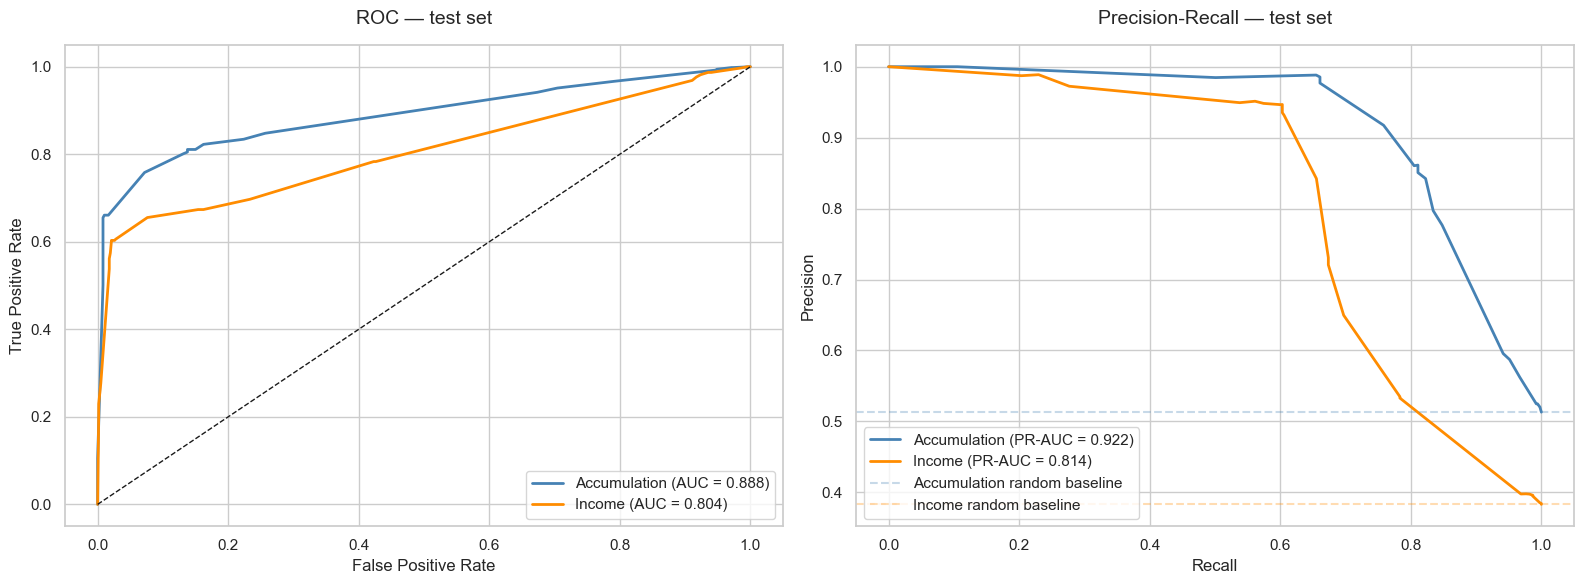

In [39]:
# Usa plot_test_curves() del notebook NN (ROC + PR in un'unica figura).
# Per il confronto DT prendiamo il feature set con PR-AUC migliore per target.
import numpy as np
from sklearn.metrics import average_precision_score

def _best_proba(t_key):
    """Restituisce le probabilita' del feature set con PR-AUC piu' alto."""
    best_p, best_ap = None, -1
    for f_key in ['base', 'engineered']:
        _, _, _, y_te = splits[(f_key, t_key)]
        p = all_results[(t_key, f_key)]['y_test_proba']
        ap = average_precision_score(y_te, p)
        if ap > best_ap:
            best_p, best_ap = p, ap
    return best_p

_, _, _, y_te_acc = splits[('base', 'accum')]
_, _, _, y_te_inc = splits[('base', 'income')]

plot_test_curves(
    y_acc=y_te_acc.values, p_acc=_best_proba('accum'),
    y_inc=y_te_inc.values, p_inc=_best_proba('income'),
)

In [40]:
# Precision-Recall gia' inclusa in plot_test_curves() nella cella precedente.

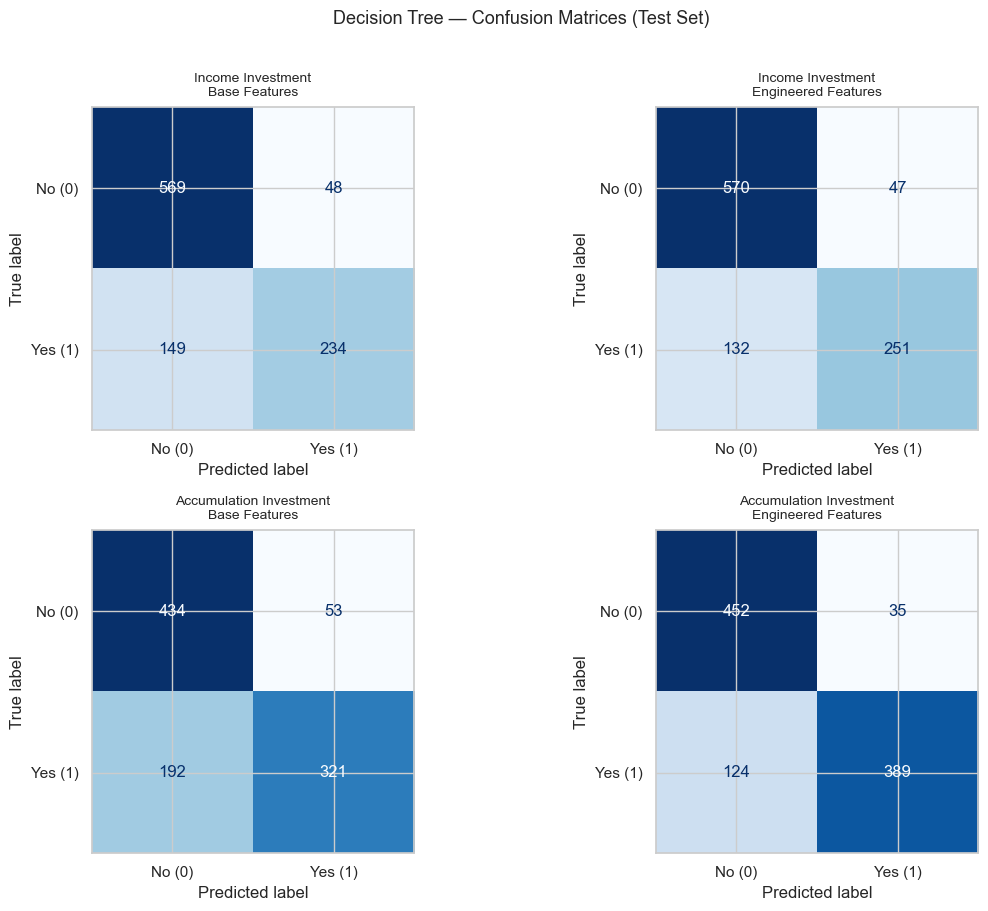

In [41]:
plot_confusion_matrices(splits, all_results, TARGET_CONFIG, FEATURE_CONFIG)

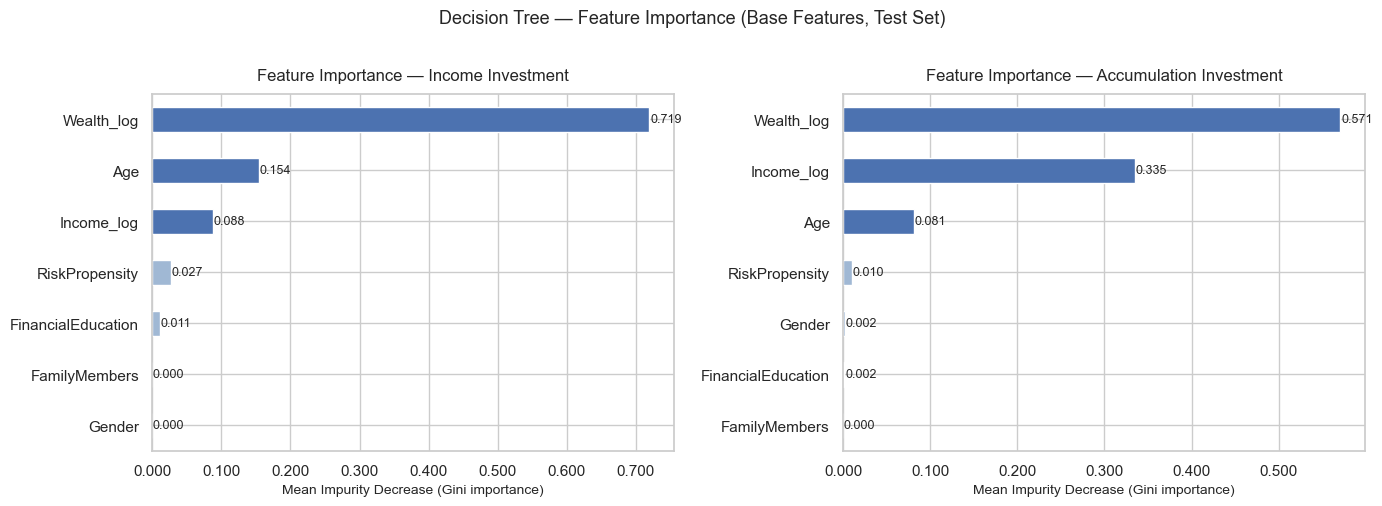

In [42]:
plot_feature_importance(all_results, TARGET_CONFIG, feature_set='base')

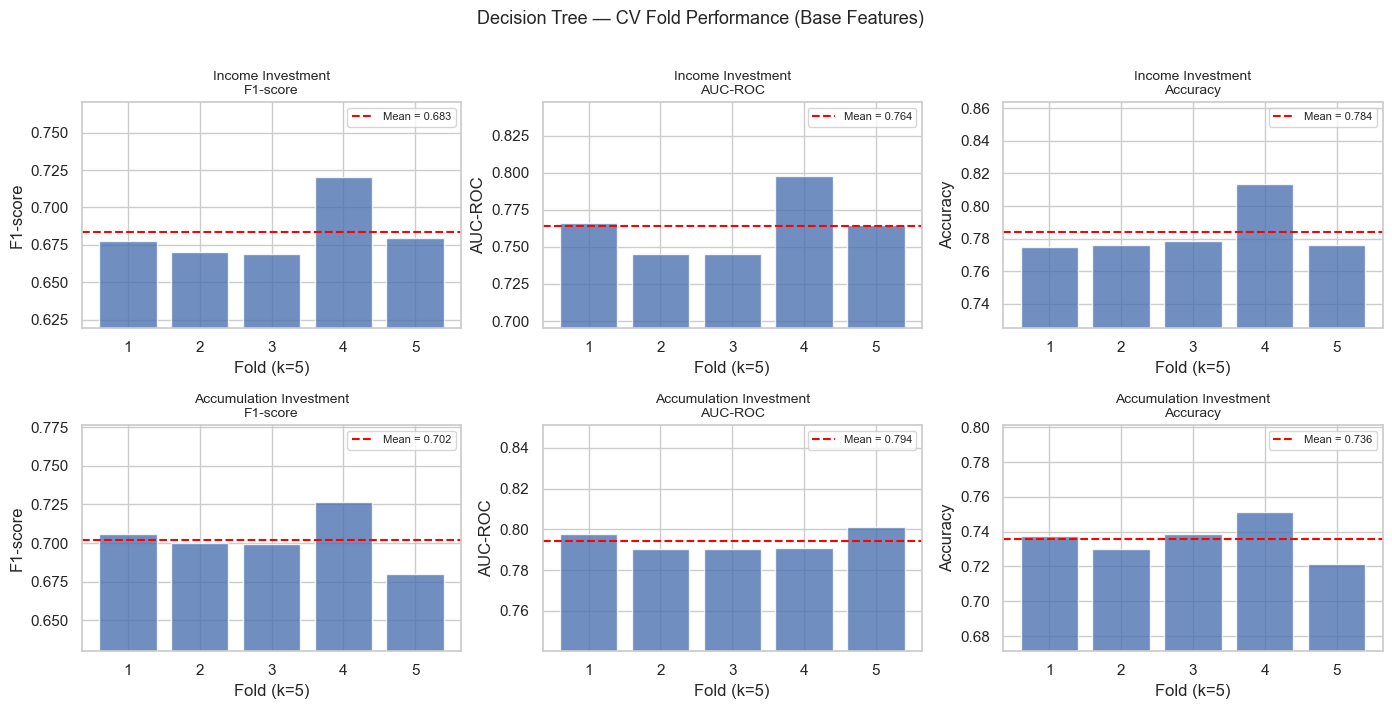

In [43]:
# Per-fold CV stability chart
plot_cv_fold_performance(splits, TARGET_CONFIG, DT_BASELINE,
                          k_folds=5, random_state=RANDOM_STATE)

## 6 — Tree visualisation (baseline)

Plotting the top 3 levels gives an interpretable view of the most important
splits without rendering the full deep tree.

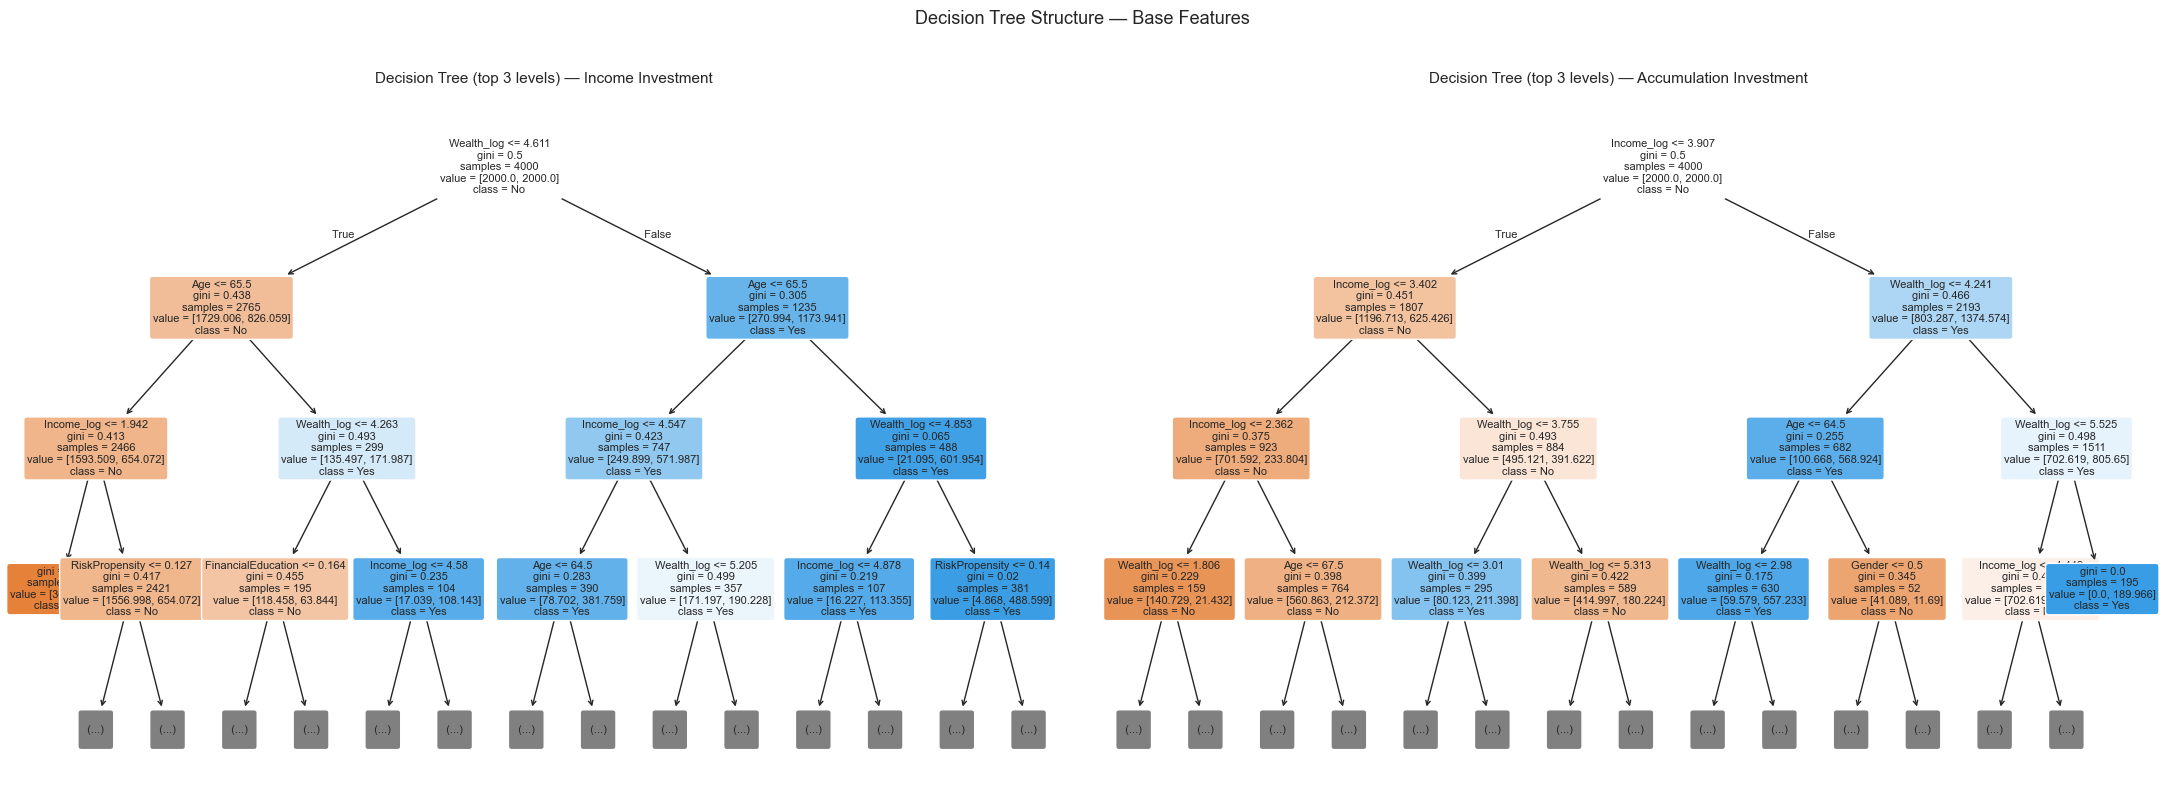


=== Text representation (Income Investment, depth ≤ 3) ===
|--- Wealth_log <= 4.61
|   |--- Age <= 65.50
|   |   |--- Income_log <= 1.94
|   |   |   |--- class: 0
|   |   |--- Income_log >  1.94
|   |   |   |--- RiskPropensity <= 0.13
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- RiskPropensity >  0.13
|   |   |   |   |--- truncated branch of depth 2
|   |--- Age >  65.50
|   |   |--- Wealth_log <= 4.26
|   |   |   |--- FinancialEducation <= 0.16
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- FinancialEducation >  0.16
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- Wealth_log >  4.26
|   |   |   |--- Income_log <= 4.58
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- Income_log >  4.58
|   |   |   |   |--- class: 0
|--- Wealth_log >  4.61
|   |--- Age <= 65.50
|   |   |--- Income_log <= 4.55
|   |   |   |--- Age <= 64.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- Age >  64.50
|   |   |   |   

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(22, 8))

for ax, (t_key, t_label, _) in zip(axes, TARGET_CONFIG):
    res   = all_results[(t_key, 'base')]
    model = res['model']
    plot_tree(
        model,
        feature_names = res['feature_names'],
        class_names   = ['No', 'Yes'],
        filled=True, rounded=True, max_depth=3, fontsize=8, ax=ax
    )
    ax.set_title(f'Decision Tree (top 3 levels) — {t_label}', fontsize=11, pad=10)

plt.suptitle('Decision Tree Structure — Base Features', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Text representation for documentation / reproducibility
print('\n=== Text representation (Income Investment, depth ≤ 3) ===')
print(export_text(all_results[('income', 'base')]['model'],
                  feature_names=all_results[('income', 'base')]['feature_names'],
                  max_depth=3))

## 7 — Optuna hyperparameter tuning

Maximises mean AUC-PR on a 3-fold inner CV (fast proxy).  The winning
configuration is then re-evaluated with the full 5-fold CV and the held-out
test set.

In [45]:
# Increase N_TRIALS for a more thorough search (40+ recommended for production)
N_TRIALS = 50

tuned_results  = {}
tuning_summary = []

for t_key, t_label, _ in TARGET_CONFIG:
    print(f'\n{"="*65}')
    print(f'  TARGET: {t_label}')
    print(f'{"="*65}')

    for f_key, f_label, _ in FEATURE_CONFIG:
        X_train, X_test, y_train, y_test = splits[(f_key, t_key)]

        print(f'\n  [{f_label}] — searching {N_TRIALS} trials...')
        best_model, study = optimize_dt(X_train, y_train,
                                         n_trials=N_TRIALS,
                                         random_state=RANDOM_STATE)

        # 5-fold evaluation with the best hyperparameters
        results = train_evaluate_dt(X_train, y_train, X_test, y_test, best_model)
        tuned_results[(t_key, f_key)] = results
        display_results_table(results, 'DT Optuna', f_label, t_label)

        tuning_summary.append({
            'Target'         : t_label,
            'Features'       : f_label,
            'Best CV AUC-PR' : round(study.best_value, 4),
            'Test AUC-PR'    : round(results['test_metrics']['auc_pr'], 4),
            'Test F1'        : round(results['test_metrics']['f1'], 4),
            **{k: study.best_params[k]
               for k in ['max_depth', 'min_samples_leaf', 'criterion', 'class_weight']},
        })

print('\nOptuna tuning complete.')


  TARGET: Income Investment

  [Base Features] — searching 50 trials...

  DT Optuna | Base Features | Income Investment  
    Metric     CV (mean ± std)  Test Set
  Accuracy  0.793 ± 0.015    0.806
 Precision  0.831 ± 0.041    0.889
    Recall  0.579 ± 0.025    0.564
  F1-score  0.682 ± 0.022    0.690
   AUC-ROC  0.774 ± 0.020    0.794
    AUC-PR  0.758 ± 0.023    0.780


  [Engineered Features] — searching 50 trials...

  DT Optuna | Engineered Features | Income Investment  
    Metric     CV (mean ± std)  Test Set
  Accuracy  0.784 ± 0.019    0.818
 Precision  0.795 ± 0.041    0.860
    Recall  0.592 ± 0.027    0.627
  F1-score  0.678 ± 0.027    0.725
   AUC-ROC  0.780 ± 0.018    0.812
    AUC-PR  0.755 ± 0.029    0.815


  TARGET: Accumulation Investment

  [Base Features] — searching 50 trials...

  DT Optuna | Base Features | Accumulation Investment  
    Metric     CV (mean ± std)  Test Set
  Accuracy  0.779 ± 0.014    0.781
 Precision  0.829 ± 0.032    0.830
    Recall  0.718 

In [46]:
# Summary table of best parameters and final test performance
tuning_df = pd.DataFrame(tuning_summary)
print('=== Optuna — Best Parameters and Test Performance ===')
print(tuning_df.to_string(index=False))

=== Optuna — Best Parameters and Test Performance ===
                 Target            Features  Best CV AUC-PR  Test AUC-PR  Test F1  max_depth  min_samples_leaf criterion class_weight
      Income Investment       Base Features          0.7638       0.7805   0.6901         14                44   entropy         None
      Income Investment Engineered Features          0.7694       0.8148   0.7251         15                31   entropy         None
Accumulation Investment       Base Features          0.8638       0.8812   0.7716         10                18   entropy         None
Accumulation Investment Engineered Features          0.8921       0.9113   0.8423          9                50   entropy         None


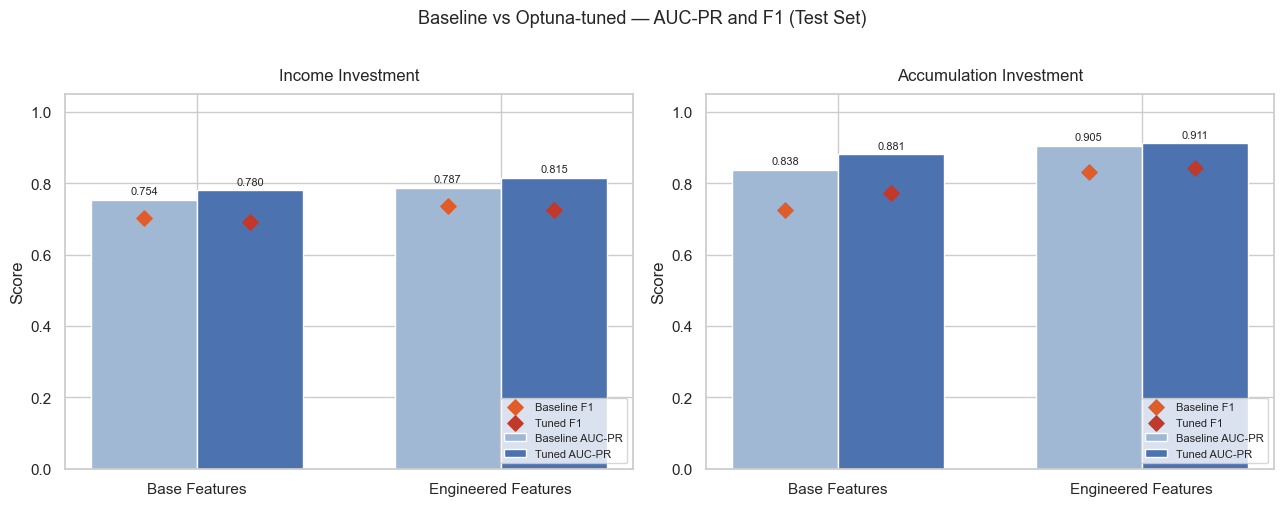

In [47]:
# Visual comparison: baseline vs tuned
plot_baseline_vs_tuned(all_results, tuned_results, TARGET_CONFIG, FEATURE_CONFIG)

## 8 — Classification reports (baseline)

In [48]:
for f_key, f_label in [('base', 'Base Features'), ('engineered', 'Engineered Features')]:
    print(f'\n{"─"*60}')
    print(f'  FEATURE SET: {f_label}')
    print(f'{"─"*60}')
    for t_key, t_label, _ in TARGET_CONFIG:
        res = all_results[(t_key, f_key)]
        _, _, _, y_test = splits[(f_key, t_key)]
        print(f'\nTarget: {t_label}')
        print(classification_report(y_test, res['y_test_pred'],
                                    target_names=['No need (0)', 'Has need (1)']))


────────────────────────────────────────────────────────────
  FEATURE SET: Base Features
────────────────────────────────────────────────────────────

Target: Income Investment
              precision    recall  f1-score   support

 No need (0)       0.79      0.92      0.85       617
Has need (1)       0.83      0.61      0.70       383

    accuracy                           0.80      1000
   macro avg       0.81      0.77      0.78      1000
weighted avg       0.81      0.80      0.80      1000


Target: Accumulation Investment
              precision    recall  f1-score   support

 No need (0)       0.69      0.89      0.78       487
Has need (1)       0.86      0.63      0.72       513

    accuracy                           0.76      1000
   macro avg       0.78      0.76      0.75      1000
weighted avg       0.78      0.76      0.75      1000


────────────────────────────────────────────────────────────
  FEATURE SET: Engineered Features
─────────────────────────────────────

## 9 — Save DT predictions (for model comparison)

We store the test-set probabilities from the best (highest AUC-PR) feature
set for each target so they can be compared against other model families.

In [49]:
from pathlib import Path
from sklearn.metrics import average_precision_score

Path('compare_preds').mkdir(exist_ok=True)

def pick_best_dt(t_key: str) -> np.ndarray:
    """Return test probabilities from the feature set with higher test AUC-PR."""
    best_f, best_ap, best_proba = None, -1.0, None
    for f_key in ['base', 'engineered']:
        res   = tuned_results[(t_key, f_key)]
        _, X_te, _, y_te = splits[(f_key, t_key)]
        proba = res['model'].predict_proba(X_te)[:, 1]
        ap    = average_precision_score(y_te, proba)
        if ap > best_ap:
            best_f, best_ap, best_proba = f_key, ap, proba
    print(f'  DT {t_key}: winner = {best_f} features  (PR-AUC = {best_ap:.4f})')
    return best_proba

p_acc_dt = pick_best_dt('accum')
p_inc_dt = pick_best_dt('income')

np.save('compare_preds/dt_p_acc_test.npy', p_acc_dt)
np.save('compare_preds/dt_p_inc_test.npy', p_inc_dt)
print('DT predictions saved to compare_preds/')

  DT accum: winner = engineered features  (PR-AUC = 0.9113)
  DT income: winner = engineered features  (PR-AUC = 0.8148)
DT predictions saved to compare_preds/


## 10 — Explainability: SHAP

We explain the **tuned** models (best-performing configuration) on the test set.
Global plots show aggregate feature impact; local waterfall plots explain
individual client predictions.

In [50]:
# Build test-split lookup dict expected by SHAP helpers
test_splits = {
    (t_key, f_key): splits[(f_key, t_key)][1]   # index 1 = X_test
    for t_key in ['income', 'accum']
    for f_key in ['base', 'engineered']
}

# Compute TreeExplainer + SHAP values for all four combinations
explainers, shap_pos = build_explainers(tuned_results, test_splits)
print('SHAP explainers built.')

SHAP explainers built.


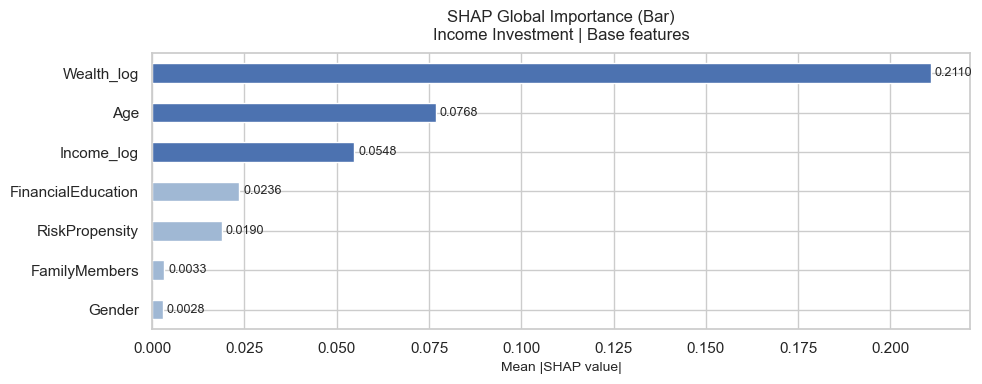

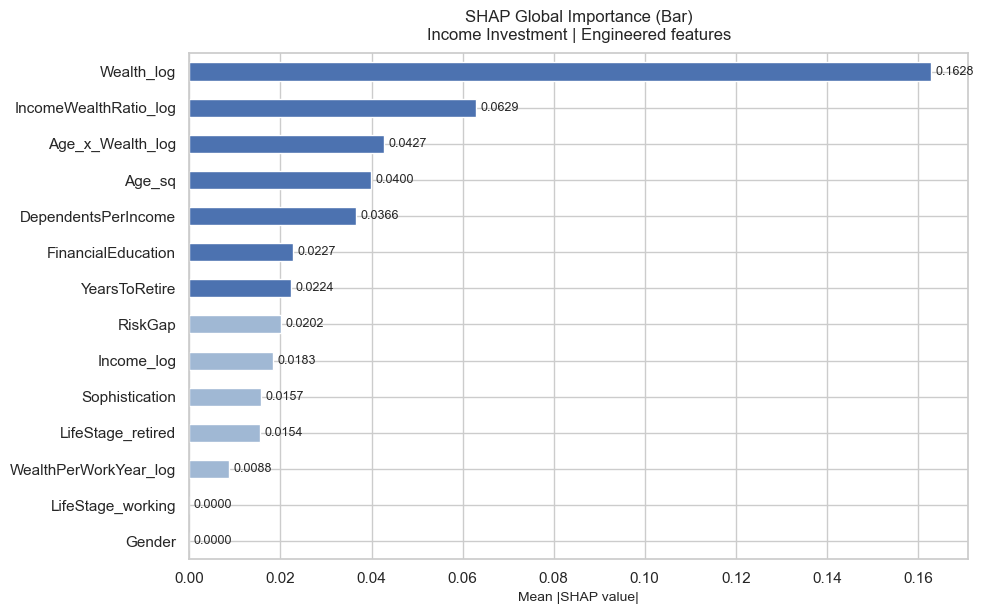

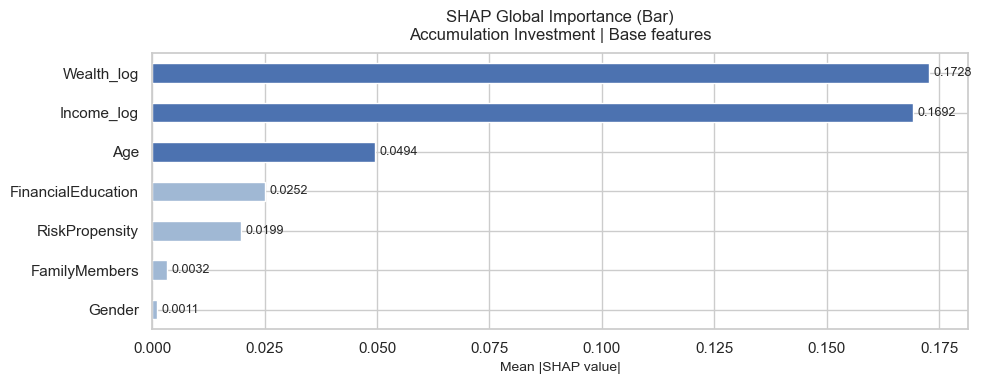

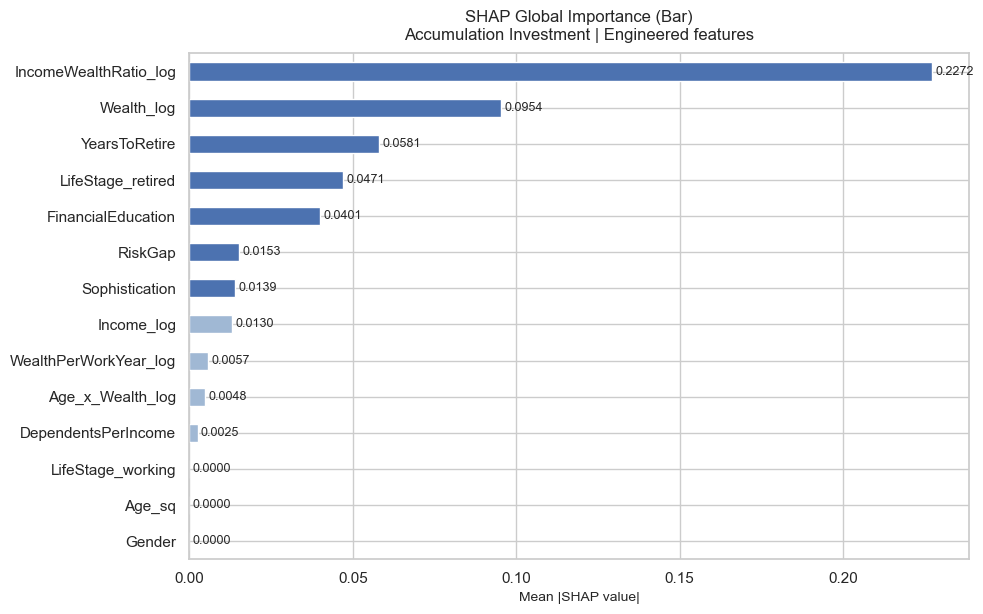

In [51]:
# Labels for each combination — reused by all SHAP plots
SHAP_COMBOS = [
    ('income', 'base',       'Income Investment | Base features'),
    ('income', 'engineered', 'Income Investment | Engineered features'),
    ('accum',  'base',       'Accumulation Investment | Base features'),
    ('accum',  'engineered', 'Accumulation Investment | Engineered features'),
]

# 10.1  Global SHAP bar (mean |SHAP value|)
plot_shap_bar(shap_pos, test_splits, SHAP_COMBOS)

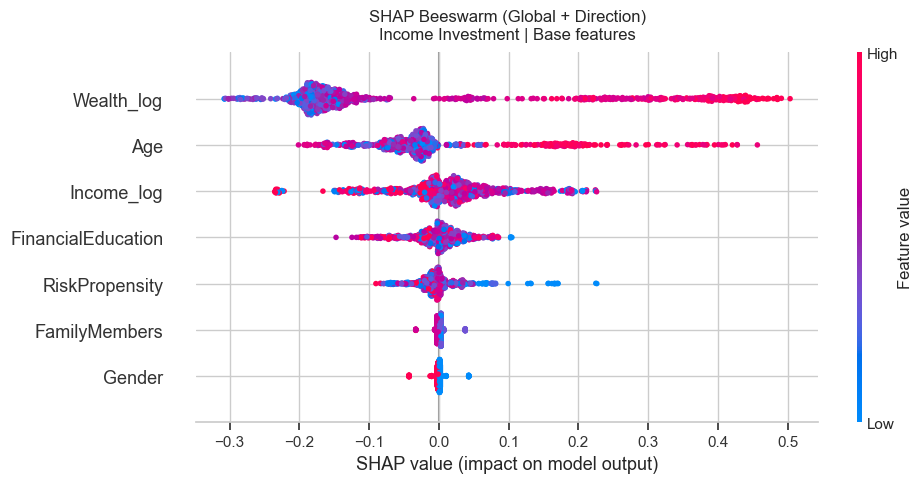

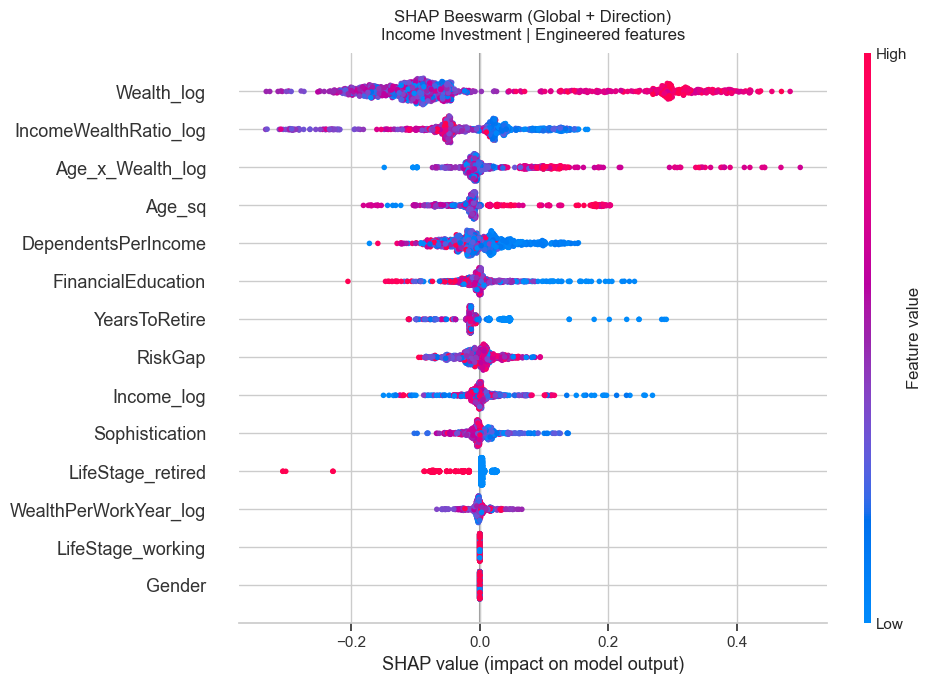

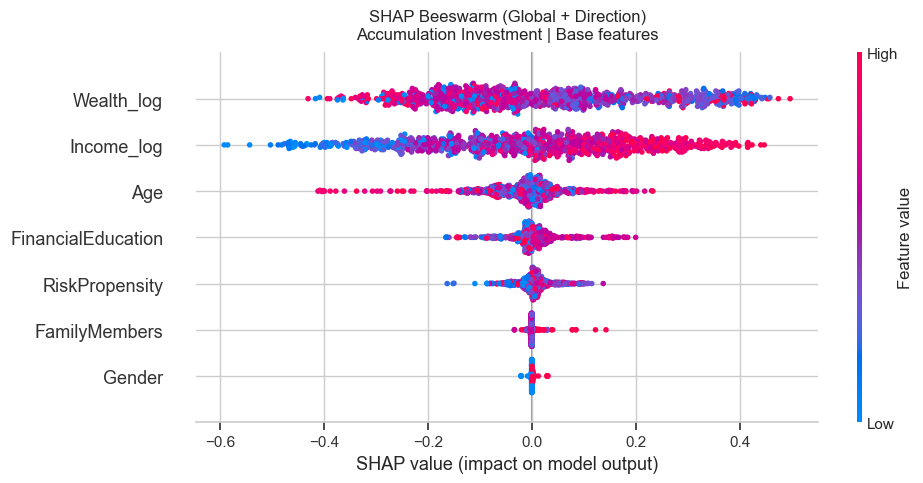

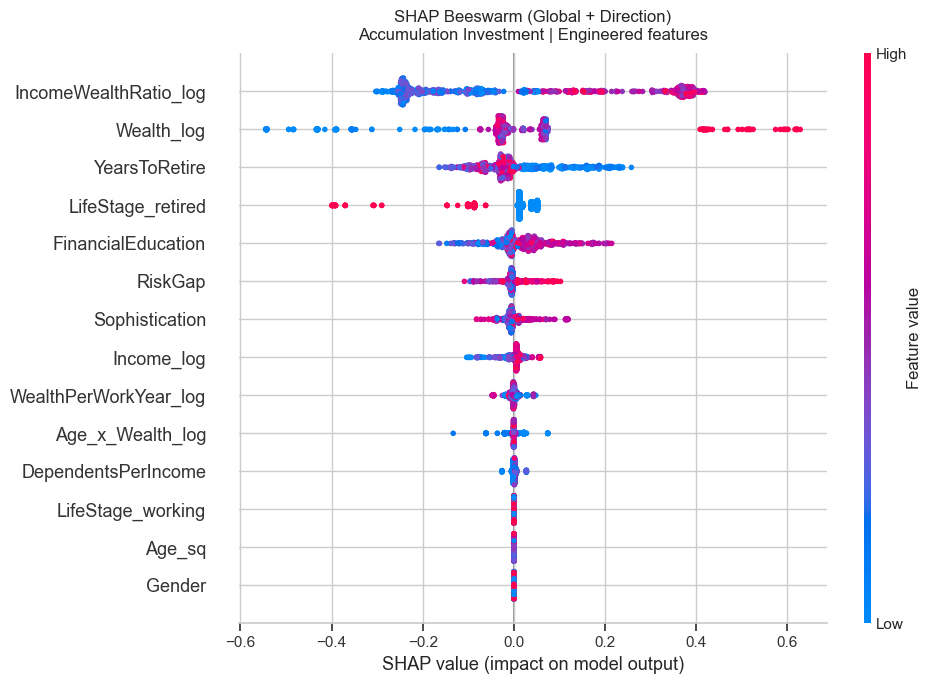

In [52]:
# 10.2  Global SHAP beeswarm (direction + distribution)
plot_shap_beeswarm(shap_pos, test_splits, SHAP_COMBOS)

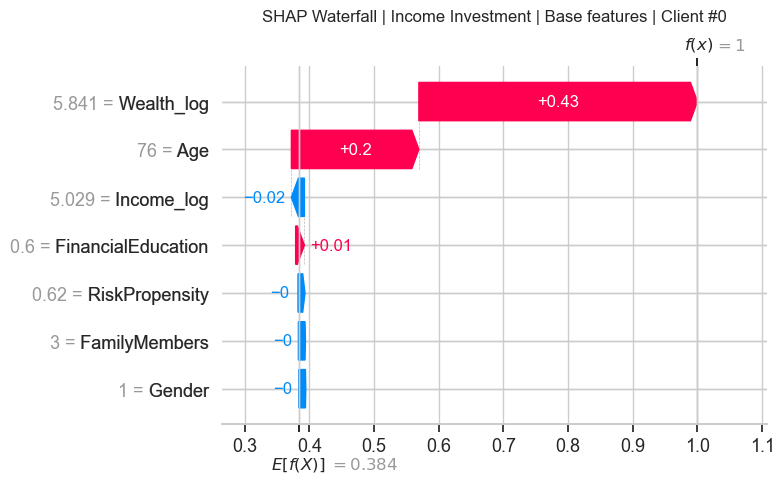

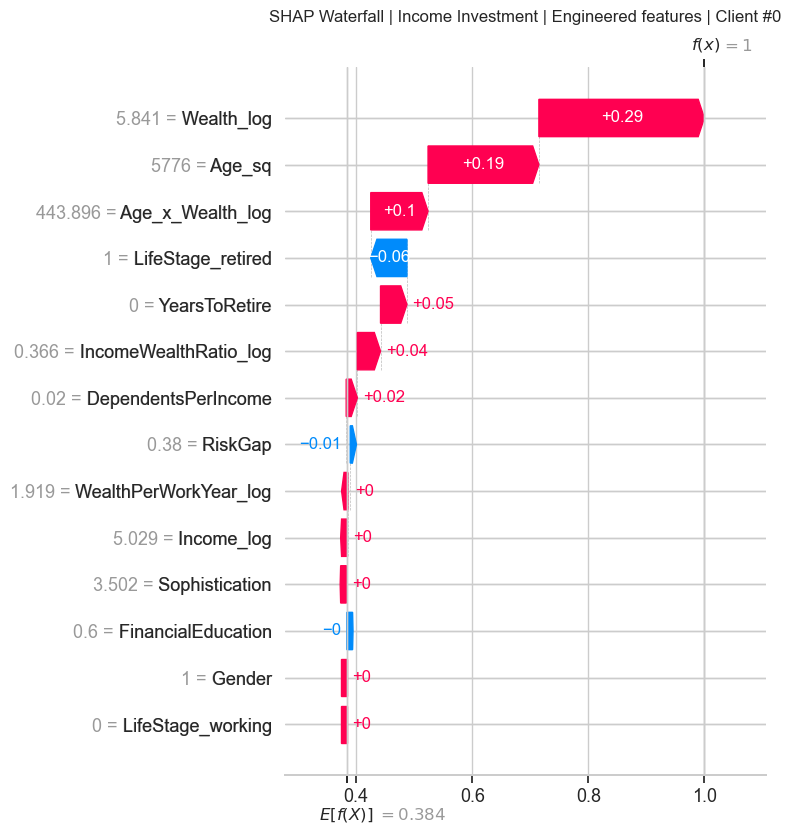

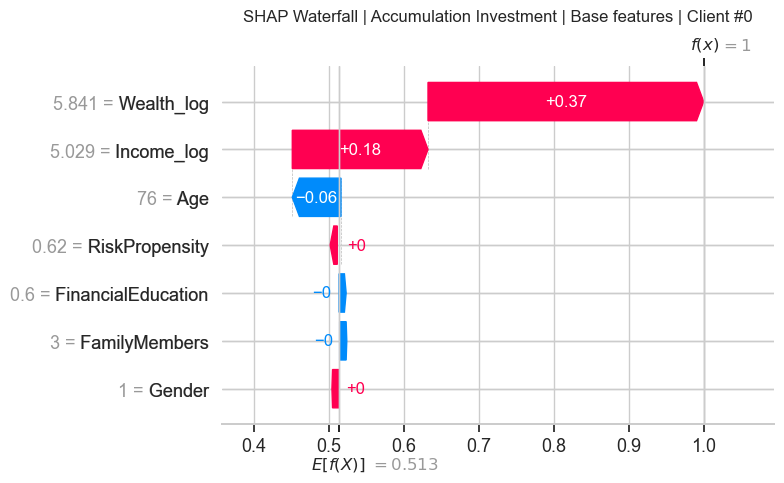

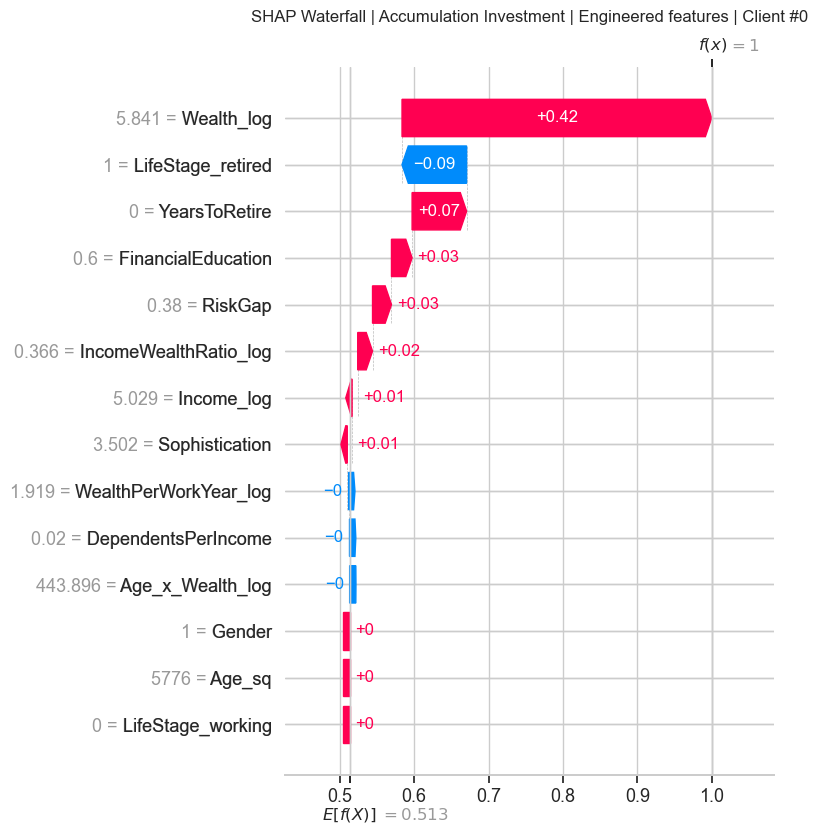

In [53]:
# 10.3  Local SHAP waterfall for a single client — change client_idx to inspect others
CLIENT_IDX = 0
plot_shap_waterfall(shap_pos, test_splits, explainers, SHAP_COMBOS,
                     client_idx=CLIENT_IDX)

## 11 — Permutation importance (model-agnostic)

Complements SHAP by directly measuring how much PR-AUC drops when each
feature is randomly shuffled.  Unlike Gini importance, this approach is
unbiased for high-cardinality and correlated features.

In [54]:
print('Computing permutation importance on the engineered TEST set...')

_, X_eng_test_inc, _, y_eng_test_inc = splits[('engineered', 'income')]
_, X_eng_test_acc, _, y_eng_test_acc = splits[('engineered', 'accum')]

model_inc_tuned = tuned_results[('income', 'engineered')]['model']
model_acc_tuned = tuned_results[('accum',  'engineered')]['model']

feat_names_eng  = list(X_eng_test_inc.columns)

perm_df_inc, base_ap_inc = permutation_importance_dt(
    model_inc_tuned, X_eng_test_inc, y_eng_test_inc, feat_names_eng,
    n_repeats=10, seed=RANDOM_STATE
)
perm_df_acc, base_ap_acc = permutation_importance_dt(
    model_acc_tuned, X_eng_test_acc, y_eng_test_acc, feat_names_eng,
    n_repeats=10, seed=RANDOM_STATE
)

print(f'Baseline PR-AUC  |  Income: {base_ap_inc:.4f}   Accumulation: {base_ap_acc:.4f}')

Computing permutation importance on the engineered TEST set...
Baseline PR-AUC  |  Income: 0.8148   Accumulation: 0.9113


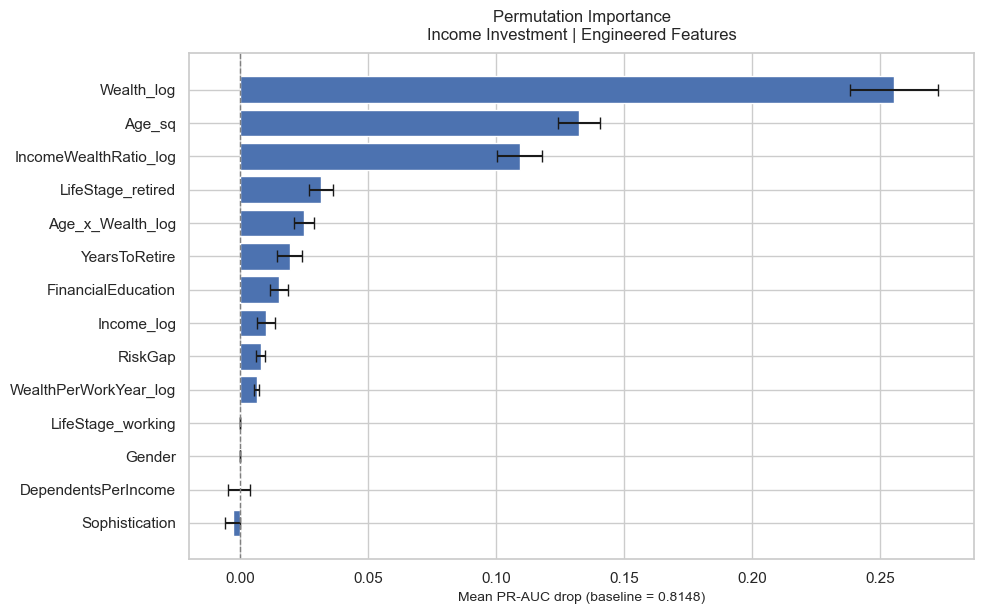

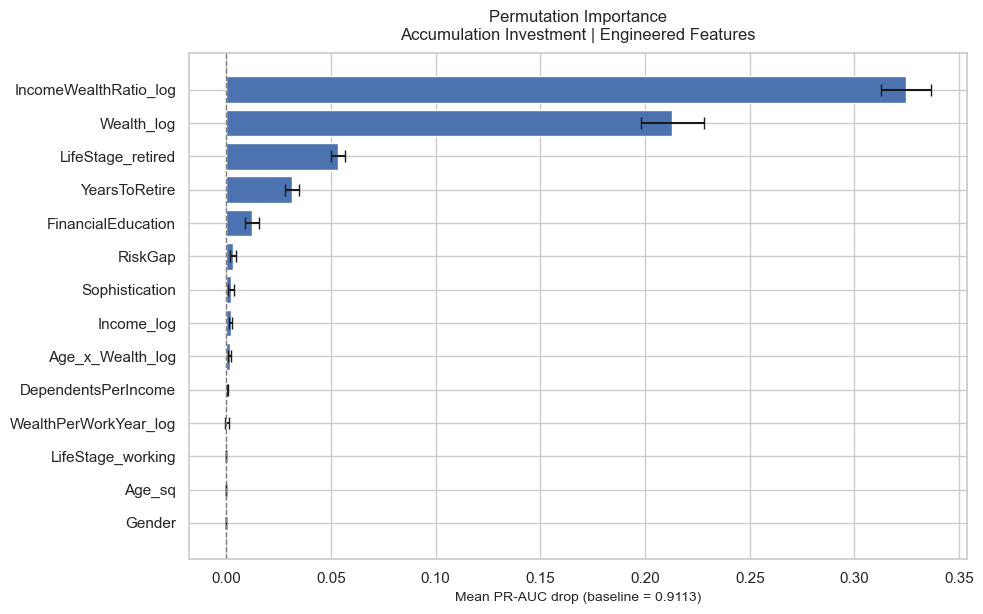

In [55]:
plot_permutation_importance(
    perm_df_inc, base_ap_inc,
    'Income Investment | Engineered Features'
)
plot_permutation_importance(
    perm_df_acc, base_ap_acc,
    'Accumulation Investment | Engineered Features'
)

## 12 — Next Best Action (NBA) — Recommendation Engine

The three-step pipeline:
1. **Predict needs** on the full dataset using the tuned engineered models.
2. **Score** every client-product pair via a MiFID-compliant composite score.
3. **Recommend** the top-3 products per client and analyse coverage.

In [56]:
# Attach mock business utility scores to products.
# In production: replace with the real margin / utility table.
#
# WHY np.random.default_rng(0) instead of np.random.seed(0):
# np.random.seed() sets the GLOBAL random state, which is shared by
# sklearn, Optuna, and everything else that ran above.  Calling seed(0)
# here would reset it and make all subsequent draws reproducible — but
# only if nothing else consumes the global RNG between this cell and
# the original notebook's execution order.  Since we refactored the
# code into helper functions, the number of internal RNG calls in those
# functions may differ from the original inline code, shifting the
# global state and producing different Utility values.
#
# The fix: use a PRIVATE Generator (new-style numpy API, introduced in
# numpy 1.17).  default_rng() creates an independent BitGenerator that
# is completely isolated from the global state — no matter how many
# other numpy calls happen before or after, this generator always
# produces the same sequence given the same seed.
_rng_utility = np.random.default_rng(seed=0)   # isolated, never touches global RNG
products_df['Utility'] = _rng_utility.uniform(0.6, 1.0, size=len(products_df))

# Rebuild full feature matrices (all 5,000 clients)
X_base_full, X_eng_full = prepare_features(needs_df)

# Tuned engineered models for probability scores
model_inc_eng = tuned_results[('income', 'engineered')]['model']
model_acc_eng = tuned_results[('accum',  'engineered')]['model']

# P(need) for every client in the full dataset
p_inc_all = model_inc_eng.predict_proba(X_eng_full)[:, 1]
p_acc_all = model_acc_eng.predict_proba(X_eng_full)[:, 1]

NEED_THRESHOLD = 0.5

print(f'Predictions on full dataset: {len(needs_df):,} clients')
print(f'  P(income need)  >= {NEED_THRESHOLD}: '
      f'{(p_inc_all >= NEED_THRESHOLD).sum():,} ({(p_inc_all >= NEED_THRESHOLD).mean():.1%})')
print(f'  P(accum  need)  >= {NEED_THRESHOLD}: '
      f'{(p_acc_all >= NEED_THRESHOLD).sum():,} ({(p_acc_all >= NEED_THRESHOLD).mean():.1%})')

Predictions on full dataset: 5,000 clients
  P(income need)  >= 0.5: 1,474 (29.5%)
  P(accum  need)  >= 0.5: 2,173 (43.5%)


In [57]:
# Generate top-3 compliant recommendations for every client
# owned_lookup = {} means no existing holdings are assumed
recs_df = generate_recommendations(
    needs_df, products_df, p_inc_all, p_acc_all,
    owned_lookup={}, top_k=3
)

print('Top-3 recommendations (first 10 clients):')
print(recs_df.head(10).to_string(index=False))
print(f"\nClients with ≥ 1 eligible product: "
      f"{recs_df['Rec_1'].notna().sum():,} / {len(recs_df):,} "
      f"({recs_df['Rec_1'].notna().mean():.1%})")

Top-3 recommendations (first 10 clients):
 ClientIdx  Rec_1  Score_1  Rec_2  Score_2  Rec_3  Score_3
         0    9.0   0.8030   10.0   0.3537    3.0   0.2224
         1   10.0   0.9692    3.0   0.6116    NaN   0.0000
         2   10.0   0.1244    9.0   0.0859    3.0   0.0781
         3    1.0   0.8272    8.0   0.8139    5.0   0.7733
         4    6.0   0.1988    9.0   0.1653   10.0   0.0816
         5    6.0   0.8985    5.0   0.8955    8.0   0.8886
         6    6.0   0.9472    5.0   0.9063    9.0   0.7753
         7   10.0   0.0374    3.0   0.0235    NaN   0.0000
         8   10.0   0.9310    3.0   0.5873    NaN   0.0000
         9   10.0   0.7106    2.0   0.6592    4.0   0.6062

Clients with ≥ 1 eligible product: 4,863 / 5,000 (97.3%)


In [58]:
# Catalogue-gap decomposition
coverage_df = analyse_coverage(
    needs_df, recs_df, p_inc_all, p_acc_all,
    need_threshold=NEED_THRESHOLD
)

=== REFINED COVERAGE: why are some clients not covered? ===
                                             Segment  Clients  Pct (%)
                 No need predicted (correct silence)      105      2.1
Catalogue gap (need predicted, no compliant product)       32      0.6
                 At least one recommendation emitted     4863     97.3

Partial catalogue gaps (per need head):
  Accumulation need predicted but NO compatible product: 22
  Income        need predicted but NO compatible product: 17

Business insight: catalogue gap clients are actionable — the model correctly
identified a need, but no product in the current catalogue fits their risk
tolerance.  This is a product line opportunity, not a model limitation.


### 12.1 — Recommendation visualisations

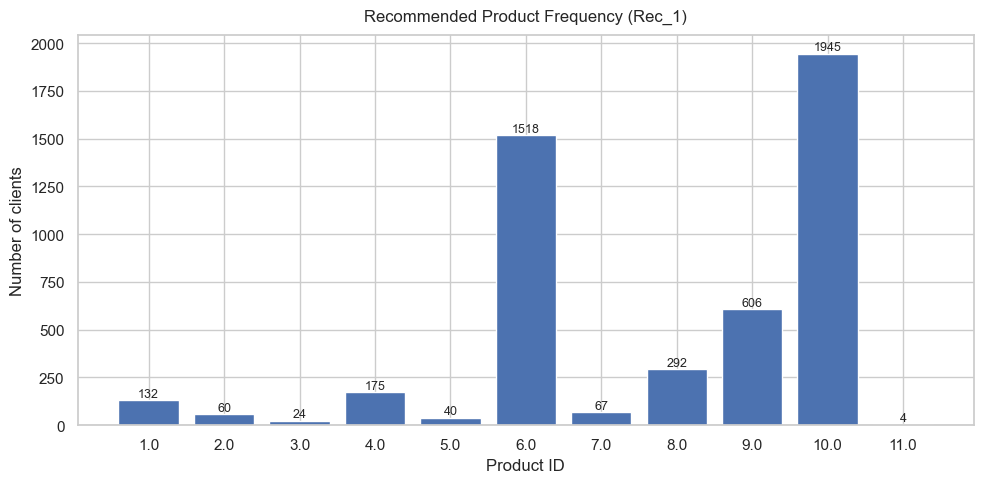

In [59]:
plot_recommendation_freq(recs_df)

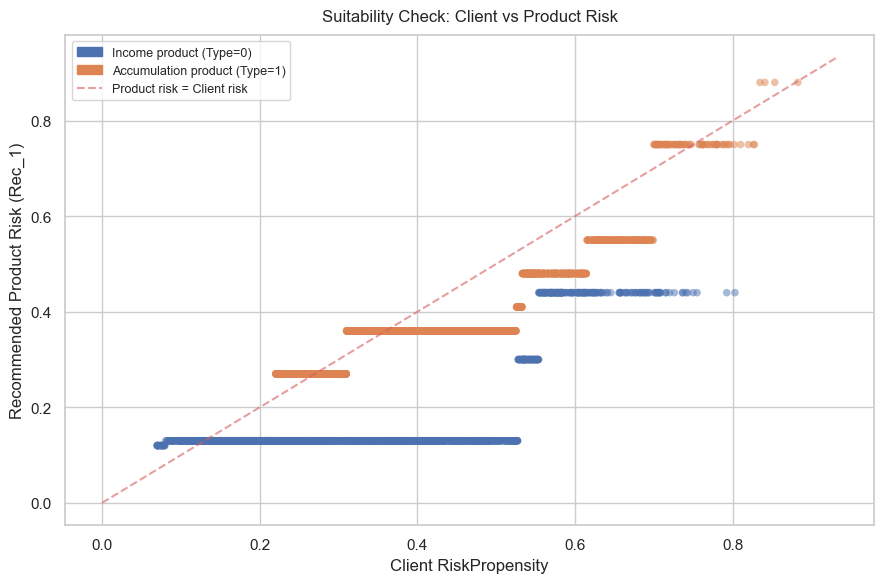

In [60]:
plot_suitability_scatter(recs_df, products_df, needs_df)

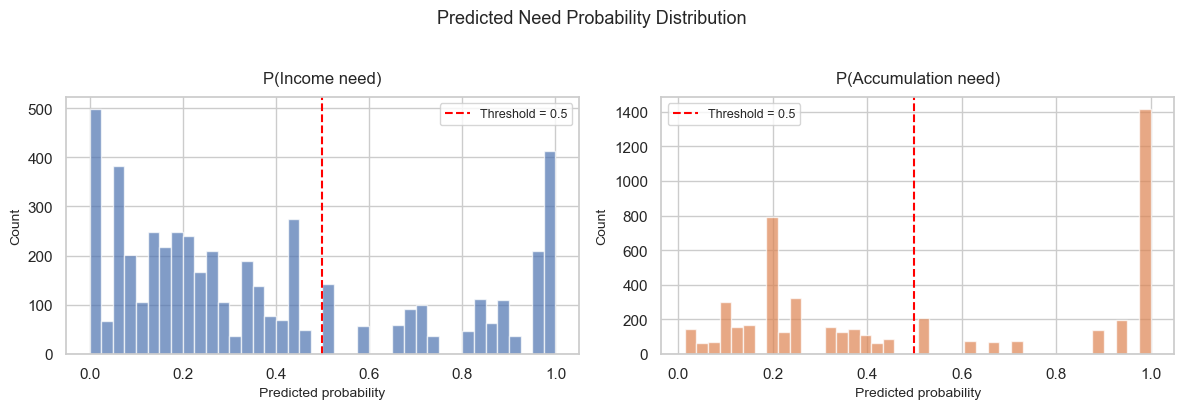

In [61]:
plot_need_probability_hist(p_inc_all, p_acc_all, need_threshold=NEED_THRESHOLD)

In [62]:
# Full product breakdown with recommendation counts
rec_counts = (
    recs_df[recs_df['Rec_1'].notna()]
    .groupby('Rec_1').size()
    .reset_index(name='n_recommendations')
    .rename(columns={'Rec_1': 'IDProduct'})
    .merge(products_df[['IDProduct', 'Type', 'Risk', 'Utility']],
           on='IDProduct', how='left')
    .sort_values('n_recommendations', ascending=False)
)

print('=== RECOMMENDED PRODUCTS — FULL BREAKDOWN ===')
print(rec_counts[['IDProduct', 'Type', 'Risk', 'Utility',
                   'n_recommendations']].to_string(index=False))

print('\n=== Top 3 Most Recommended Products ===')
for _, row in rec_counts.head(3).iterrows():
    need_name = 'Accumulation' if row['Type'] == 1 else 'Income'
    print(f'  Product {int(row.IDProduct):>2}  |  {need_name:<14}  |  '
          f'Risk: {row.Risk:.2f}  |  Utility: {row.Utility:.2f}  |  '
          f'{int(row.n_recommendations):>5} recommendations')

=== RECOMMENDED PRODUCTS — FULL BREAKDOWN ===
 IDProduct  Type  Risk  Utility  n_recommendations
      10.0     0  0.13 0.974029               1945
       6.0     1  0.36 0.965102               1518
       9.0     1  0.27 0.817450                606
       8.0     1  0.48 0.891799                292
       4.0     0  0.44 0.606611                175
       1.0     1  0.55 0.854785                132
       7.0     1  0.75 0.842654                 67
       2.0     0  0.30 0.707915                 60
       5.0     1  0.41 0.925308                 40
       3.0     0  0.12 0.616389                 24
      11.0     1  0.88 0.926341                  4

=== Top 3 Most Recommended Products ===
  Product 10  |  Income          |  Risk: 0.13  |  Utility: 0.97  |   1945 recommendations
  Product  6  |  Accumulation    |  Risk: 0.36  |  Utility: 0.97  |   1518 recommendations
  Product  9  |  Accumulation    |  Risk: 0.27  |  Utility: 0.82  |    606 recommendations
